# IDEAS
1. Capture the scene with minimum restrictions and see if it captures any blob. If so, create mask on the areas it does detects.
2. Get wand with one blob and flail it around - make sure it is seen by all the cameras in the capture value

In [25]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
def detect_blobs(
    gray_img,
    min_area=10,
    max_area=1000,
    min_circularity=0.3,
    min_convexity=0.3,
    min_inertia=0.3,
    thresh=200
):

    _, binary = cv2.threshold(gray_img, thresh, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    blobs = []
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if not (min_area <= area <= max_area):
            continue

        perimeter = cv2.arcLength(cnt, True)
        if perimeter == 0:
            continue

        # Circularity
        circularity = 4 * np.pi * area / (perimeter**2)
        if circularity < min_circularity:
            continue

        # Convexity
        hull = cv2.convexHull(cnt)
        hull_area = cv2.contourArea(hull)
        if hull_area == 0:
            continue
        convexity = area / hull_area
        if convexity < min_convexity:
            continue

        # Inertia Ratio
        M = cv2.moments(cnt)
        if M["m00"] == 0:
            continue
        cx = int(M["m10"] / M["m00"])
        cy = int(M["m01"] / M["m00"])
        mu20, mu02 = M["mu20"], M["mu02"]
        inertia_ratio = min(mu20, mu02) / max(mu20, mu02) if max(mu20, mu02) > 0 else 0
        if inertia_ratio < min_inertia:
            continue

        # Enclosing circle
        (x, y), radius = cv2.minEnclosingCircle(cnt)

        blobs.append(
            {
                "contour": cnt,
                "center": (cx, cy),
                "radius": radius,
                "area": area,
                "circularity": circularity,
                "convexity": convexity,
                "inertia": inertia_ratio,
            }
        )

    return blobs


# Start webcam
cap = cv2.VideoCapture(0)  # use 0 or 1 depending on your webcam

rows = []

while True:
    ret, frame = cap.read()
    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    #gray = cv2.equalizeHist(gray)  # improve contrast

    blobs = detect_blobs(gray, min_area=50, max_area=5000, min_circularity=0.75)

    for b in blobs:
        rows.append(b)

    gray = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)

    for blob in blobs:
        cx, cy = blob["center"]
        r = int(blob["radius"])
        cv2.circle(gray, (cx, cy), r, (0, 255, 0), 2)
        cv2.circle(gray, (cx, cy), 2, (0, 0, 255), -1)

    cv2.imshow("Round Blob Detection", gray)
    if cv2.waitKey(1) == 27:  # ESC to quit
        break

cap.release()
cv2.destroyAllWindows()

In [79]:
# Initial DataFrame
blob_df = pd.DataFrame(rows)

blob_df

,contour,center,radius,area,circularity,convexity,inertia
0,"[[[359, 258]], [[356, 261]], [[356, 266]], [[3...","(359, 263)",5.626673,65.0,0.790631,0.955882,0.663633
1,"[[[354, 255]], [[352, 257]], [[352, 259]], [[3...","(356, 261)",6.351493,94.0,0.826756,0.964103,0.640586
2,"[[[352, 251]], [[351, 252]], [[350, 252]], [[3...","(352, 258)",7.354130,118.5,0.828912,0.951807,0.541409
3,"[[[349, 248]], [[348, 249]], [[347, 249]], [[3...","(349, 256)",8.262402,139.0,0.803419,0.952055,0.461211
4,"[[[126, 364]], [[121, 369]], [[121, 370]], [[1...","(127, 372)",9.604787,213.5,0.783243,0.940529,0.952244
...,...,...,...,...,...,...,...
248,"[[[175, 373]], [[171, 377]], [[171, 382]], [[1...","(180, 381)",10.594911,242.0,0.870289,0.977778,0.664711
249,"[[[157, 357]], [[155, 359]], [[155, 360]], [[1...","(164, 368)",13.601571,435.5,0.833868,0.968854,0.867130
250,"[[[135, 342]], [[134, 343]], [[131, 343]], [[1...","(141, 354)",16.770609,539.5,0.769874,0.955713,0.600707
251,"[[[31, 326]], [[29, 328]], [[28, 328]], [[27, ...","(41, 341)",20.808752,739.5,0.756800,0.967932,0.710313


In [ ]:
def print_calib_values(blob_df):
    # Set print options to display floats with 2 decimal places
    np.set_printoptions(precision=2, suppress=True) 

    for feature in ["radius", "area", "circularity", "convexity", "inertia"]:
        data = blob_df[feature]

        data = np.array(data)

        Q1 = np.quantile(data, 0.25)
        Q2 = np.median(data)
        Q3 = np.quantile(data, 0.75)
        IQR = Q3 - Q1

        upper_bound = Q3 + (1.5 * IQR)
        lower_bound = Q1 - (1.5 * IQR)

        upper_whisker = np.max(np.compress(data <= upper_bound, data))
        lower_whisker = np.min(np.compress(data >= lower_bound, data))

        outliers = data[(data < lower_whisker) | (data > upper_whisker)]

        print(f"{feature.upper()}")
        print(f"\tUpper Whisker: {upper_whisker:.2f}")
        print(f"\tUpper Box: {Q3:.2f}")
        print(f"\tMedian: {Q2:.2f}")
        print(f"\tLower Box: {Q1:.2f}")
        print(f"\tLower Whisker: {lower_whisker:.2f}")

In [81]:
print_calib_values(blob_df)

RADIUS
	Upper Whisker: 7.91
	Upper Box: 6.35
	Median: 5.59
	Lower Box: 5.20
	Lower Whisker: 4.61
AREA
	Upper Whisker: 103.50
	Upper Box: 80.00
	Median: 71.50
	Lower Box: 63.50
	Lower Whisker: 50.50
CIRCULARITY
	Upper Whisker: 0.94
	Upper Box: 0.87
	Median: 0.84
	Lower Box: 0.82
	Lower Whisker: 0.75
CONVEXITY
	Upper Whisker: 1.00
	Upper Box: 0.97
	Median: 0.96
	Lower Box: 0.95
	Lower Whisker: 0.91
INERTIA
	Upper Whisker: 1.00
	Upper Box: 0.93
	Median: 0.84
	Lower Box: 0.65
	Lower Whisker: 0.36


RADIUS
	Upper Whisker: 7.91
	Upper Box: 6.35
	Median: 5.59
	Lower Box: 5.20
	Lower Whisker: 4.61
AREA
	Upper Whisker: 103.50
	Upper Box: 80.00
	Median: 71.50
	Lower Box: 63.50
	Lower Whisker: 50.50
CIRCULARITY
	Upper Whisker: 0.94
	Upper Box: 0.87
	Median: 0.84
	Lower Box: 0.82
	Lower Whisker: 0.75
CONVEXITY
	Upper Whisker: 1.00
	Upper Box: 0.97
	Median: 0.96
	Lower Box: 0.95
	Lower Whisker: 0.91
INERTIA
	Upper Whisker: 1.00
	Upper Box: 0.93
	Median: 0.84
	Lower Box: 0.65
	Lower Whisker: 0.36


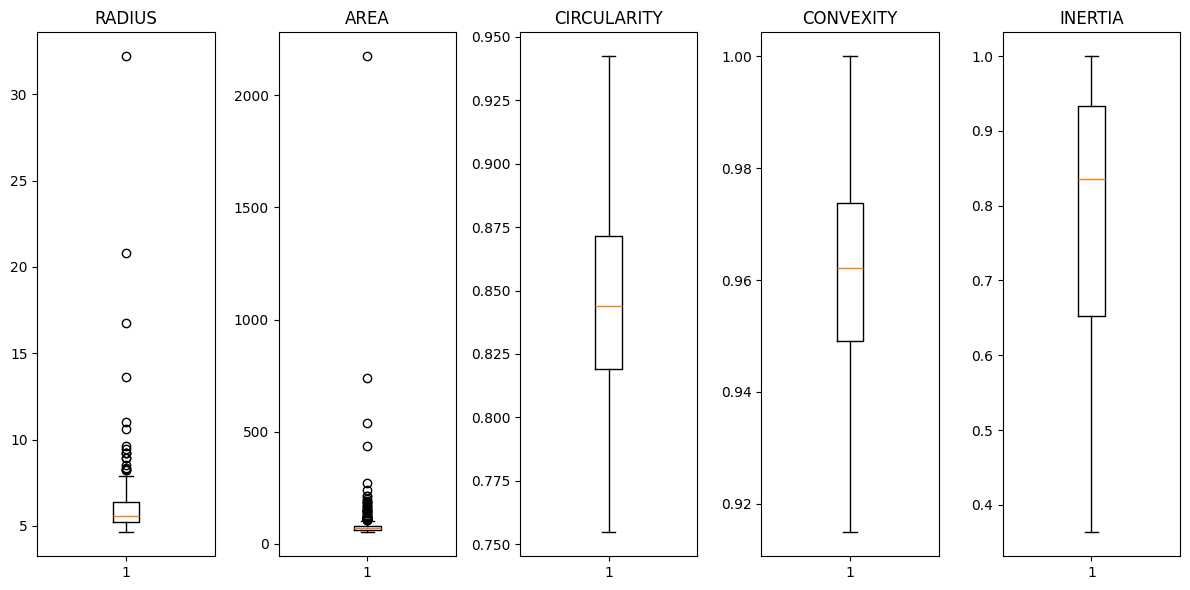

In [82]:
# Set print options to display floats with 2 decimal places
np.set_printoptions(precision=2, suppress=True) 

figure, axis = plt.subplots(1, 5)
figure.set_size_inches(12, 6)

for plot_id, feature in enumerate(["radius", "area", "circularity", "convexity", "inertia"]):
    data = blob_df[feature]
    
    axis[plot_id].set_title(feature.upper())
    bp = axis[plot_id].boxplot(data)

    data = np.array(data)

    Q1 = np.quantile(data, 0.25)
    Q2 = np.median(data)
    Q3 = np.quantile(data, 0.75)
    IQR = Q3 - Q1

    upper_bound = Q3 + (1.5 * IQR)
    lower_bound = Q1 - (1.5 * IQR)

    upper_whisker = np.max(np.compress(data <= upper_bound, data))
    lower_whisker = np.min(np.compress(data >= lower_bound, data))

    outliers = data[(data <= lower_bound) | (data >= upper_bound)]

    print(f"{feature.upper()}")
    print(f"\tUpper Whisker: {upper_whisker:.2f}")
    print(f"\tUpper Box: {Q3:.2f}")
    print(f"\tMedian: {Q2:.2f}")
    print(f"\tLower Box: {Q1:.2f}")
    print(f"\tLower Whisker: {lower_whisker:.2f}")

# Packing all the plots and displaying them
plt.tight_layout()
plt.show()
